<a href="https://colab.research.google.com/github/mcheysser/Proyecto_Simulacion_Black_Hole/blob/main/Copia_de_Proyecto_DiscoAcrecion_RG2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p>
<h1><b><center></center></b></h1>
<center><img src="https://drive.google.com/uc?id=1UJc1ci41G6ahJ7ProKvunUOIBcTXZ6ZG" align="center" width="550"></center>
</p>
<h1><b><center>Mecánica Celeste</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h1>
<h2><b><center>Proyecto del Curso</center></b><h2>
<h3><b><center>Disco de acreción alrededor de un agujero negro</center></b><h3>
<h7><center><i>Última actualización del profesor</b>: Viernes 20 de marzo de 2026, 2:00 pm</i></center><h7>
</p>

## Enunciado

<center>
<img src="https://cdn.sci.news/images/2021/02/image_9386-AT2019dsg.jpg" align="center" width="100%"></center>

Muchos objetos astrofísicos fascinantes (núcleos galácticos activos, hipernovas, binarias de rayos X) pueden explicarse con los fenómenos que ocurren en los denominados discos de acreción alrededor de agujeros negros. En este proyecto usaremos lo visto en el curso de Relatividad y Gravitación para estudiar esos fenómenos.

El objetivo de este trabajo es desarrollar simulaciones, cálculos útiles, predicciones sobre el comportamiento de las partículas en un disco de acreción. La idea es poner en práctica lo visto en el curso, tanto en las partes de relatividad especial como en las de relatividad general, para estudiar estos sistemas.

## Algunas ideas

Existen muchas maneras de aplicar la teoría que veremos en el curso en este problema y no queremos sesgar tu elección de los temas o cálculos que quieras escoger para aplicarla. Sin embargo aquí van algunas ideas de cálculos que se podrían hacer:
- Simulación del movimiento de muchas partículas alrededor del agujero negro usando, inicialmente, la dinámica newtoniana.
- Cálculo y representación gráfica de la luz emitida por el disco y observada desde distinto ángulos, incluyendo los efectos de beaming y desplazamiento espectral.
- Simulación del jet del agujero negro usando partículas cargadas moviéndose en el campo del jet.
- Cálculo de la trayectoria de fotones para visualizar el disco de acreción desde distintos ángulos.
- Cálculo de las trayectorias de partículas usando la métrica de Schwarzschild y de Kerr.

## Entregables

El entregable del proyecto es **un notebook final de Jupyter** con una descripción de la teoría básica que uses, los experimentos numéricos que hayas realizado y las conclusiones a las que llegues con esos experimentos. Por supuesto puedes desarrollar otros programas y notebooks paralelos, pero se revisará el notebook con el reporte final.

Adicionalmente se deberá entregar **un repositorio de GitHub** que tenga todos los archivos, datos, notebooks, programas usados para este propósito. El notebook debe estar alojado en el repositorio.

## Criterios de evaluación

Una vez entregues el proyecto el profesor realizará una revisión del mismo y te lo devolverá con observaciones. En la segunda revisión emitirá un concepto cuantitativo del proyecto. Los criterios a evaluar serán:

- Correcta descripción y aplicación de la teoría.
- Originalidad de los experimentos numéricos.
- Conclusiones derivadas de los experimentos.
- Organización y extensión del reporte final.
- Ritmo de actualizaciones del repositorio de GitHub.

## Para tener en cuenta

- La solución presentada debe ser estrictamente individual. Evite resolver la tarea en parejas o en grupos que puede conducir a códigos o soluciones idénticos o muy similares.
- Los métodos y herramientas para resolver el problema deben ser los vistos en clase. El uso de herramientas diferentes puede ser una buena práctica en el mundo académico o laboral, pero en un curso puede también ser un indicio de un mal uso de las *asesorías* externa o del uso inapropiado de herramientas de Inteligencia Artificial (IA).
- El notebook entregado debe tener todos los resultados y gráficos, calculados y a la vista.  También debe ejecutarse completamente con `Ejecutar Todo` sin producir ningún error (verifique antes de entregar).
- El notebook debe tener explicaciones detalladas para cada paso del procedimiento usando celdas de texto. No debe poner una celda de código sin explicarla. En caso de incluir ecuaciones debe usar $\LaTeX$.

## 1. Dinámica del Disco: Aproximación Newtoniana y Correspondencia

En esta sección implementamos la dinámica de partículas en el disco de
acreción siguiendo la metodología de la **Clase 18** y los cuadernos de
práctica del curso. La lógica del código se sustenta en tres pilares:

### A. Principio de Correspondencia Gravitacional
Como se analizó en la **Clase 15 (Gravedad linealizada)** y la **Clase 18
(La ecuación de campo en el vacío)**, las trayectorias predichas por la
ecuación geodésica de la Relatividad General coinciden con la mecánica
newtoniana en el límite de campo débil ($|\Phi| \ll c^2$).



Bajo este principio de correspondencia, la aceleración se define como el
gradiente negativo del potencial central ($\vec{a} = -\nabla\Phi$), lo que
nos da la ecuación vectorial clásica para cada partícula:

$$\frac{d^2\vec{r}}{dt^2} = -\frac{GM}{r^3}\vec{r} = -\frac{GM}{(x^2 + y^2 + z^2)^{3/2}} (x\hat{i} + y\hat{j} + z\hat{k})$$

Esta aproximación clásica es perfectamente válida para las regiones externas
del disco, donde los efectos de curvatura extrema del espacio-tiempo aún
noticia no son dominantes.

### B. Normalización en Unidades Canónicas
Siguiendo la técnica matemática de los notebooks oficiales del curso
(`rg_2026_1-geodesicas-newton.ipynb` y `rg_2026_1-geodesicas-schwarzschild.ipynb`),
normalizamos el sistema fijando las constantes fundamentales como la unidad:

$$G = 1, \quad c = 1, \quad M = 1$$

Al definir la unidad de masa como una masa solar ($U_M = M_{\odot}$), la escala
de longitud ($U_L$) queda asociada al radio de Schwarzschild y la unidad de
tiempo ($U_T$) como el tiempo que tarda la luz en cruzar dicha distancia. Esto
mantiene las variables del código en un rango numérico óptimo.

### C. Estabilidad Numérica (Euler-Cromer) y Condiciones Iniciales
Para garantizar que la simulación sea físicamente consistente, aplicamos dos
criterios prácticos de los notebooks de geodésicas:

1. **Condición de Equilibrio:** Las partículas se distribuyen en el plano
   ecuatorial ($z = 0$) con velocidades tangenciales keplerianas:
   $$v = \sqrt{\frac{M}{r}}$$
   Esto asegura una configuración de disco estable al inicio de la simulación.
2. **Conservación de Energía:** Implementamos el algoritmo de Euler-Cromer. Al
   ser un integrador simpléctico, conserva el espacio de fase y la energía a
   largo plazo, evitando que las partículas "espiralen" artificialmente hacia
   el centro debido a errores de truncamiento numérico del software.

Importamos librerias

In [1]:
!pip install -Uq pymcel einsteinpy plotly


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.1/88.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.3 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import einsteinpy.symbolic as es
import pymcel as pc
import plotly.graph_objects as go
import plotly.io as pio
import numpy as np
import matplotlib.colors as mcolors
from scipy.integrate import solve_ivp

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


## ── Adimensionalización del Sistema ──────────────────────────────────────────

En esta sección definiremos las unidades adecuadas para modelar este tipo de
sistemas. En el espacio-tiempo, los astrónomos solemos usar unidades que
simplifiquen los problemas; así como a ciertas distancias usamos unidades
astronómicas ($UA$) o pársecs ($pc$), para este caso definiremos las llamadas
**unidades canónicas**.

Al usarlas, hacemos que las constantes fundamentales y la masa de referencia
valgan uno ($G = 1$, $c = 1$, $M = 1$). Esto elimina valores gigantescos de
las ecuaciones y evita distorsiones numéricas en las gráficas; si no fijamos
$M = 1$ en el código, las escalas de fuerza se descompensan y las partículas
no logran sostener una órbita estable alrededor del cuerpo central.

### Ecuaciones asociadas

* **Unidad de Longitud:**
  $$U_L = \frac{GM}{c^2}$$

* **Unidad de Tiempo:**
  $$U_T = \frac{U_L}{c}$$

* **Escala de Masa:** Al fijar $U_M = M_{\odot}$, el sistema se modela en
  proporción a la masa de nuestro Sol.

* **Unidad de Velocidad:**
  $$U_V = \frac{U_L}{U_T}$$

* **Unidad de Aceleración:**
  $$U_A = \frac{U_L}{U_T^2}$$
  ### Valor de $G$ en Unidades Canónicas

En este sistema de unidades, la constante de gravitación universal ($G$) se
define explícitamente con un valor de uno:

$$G = 1$$

Esto se logra al elegir de forma estratégica las unidades de escala para la
longitud ($U_L$), el tiempo ($U_T$) y la masa ($U_M$). Al combinarlas, el
valor numérico de la constante en el código se simplifica por completo:

$$G_{\text{canónica}} = G_{\text{S.I.}} \cdot \frac{U_M \cdot U_T^2}{U_L^3} = 1$$

Al valer la unidad, nos quitamos de encima el factor del Sistema Internacional
($6.674 \times 10^{-11} \text{ m}^3\text{ kg}^{-1}\text{ s}^{-2}$), evitando
así errores de redondeo numérico y desajustes en las órbitas dentro de la
simulación.

In [3]:
UM = pc.constantes.M_sun       # kg  (masa del agujero negro = 1 M_sol)
UL = pc.constantes.G * UM / pc.constantes.c**2   # metros
UT = UL / pc.constantes.c

UV = UL / UT
UA = UL / UT**2

G = pc.constantes.G * UM * UT**2 / UL**3
M=1
C = 1


## ── Configuración de Condiciones Iniciales del Disco ─────────────────────────

En esta sección establecemos el estado inicial del sistema multipartícula,
siguiendo los ejemplos de los cuadernos de *Geodésicas en la Métrica de Newton
y Schwarzschild* del curso.

### 1. Configuración Geométrica
Se asume la hipótesis astrofísica de un **disco de acreción delgado**, donde el
grosor vertical es despreciable frente a su extensión radial.

Las partículas se distribuyen aleatoriamente utilizando coordenadas polares
($r, \theta$), las cuales se transforman a la base cartesiana mediante las
relaciones estándar:

$$x = r \cos(\theta), \quad y = r \sin(\theta), \quad z = 0$$

Esta distribución nos permite acotar el sistema en un rango radial que va
desde $r_{\text{min}} = 3.0$ hasta $r_{\text{max}} = 10.0$ unidades de
longitud ($U_L$).

### 2. Velocidad Orbital y Equilibrio Mecánico
Para garantizar un balance dinámico que evite el colapso o la dispersión
inmediata de la materia, descomponemos vectorialmente la velocidad circular
para que sea estrictamente perpendicular al vector de posición radial $\vec{r}$:

$$v_x = -v_{\text{circ}} \sin(\theta), \quad v_y = v_{\text{circ}} \cos(\theta), \quad v_z = 0$$

Esto asegura un movimiento puramente tangencial en el plano $XY$.

### 3. Estructura de Datos para la Evolución Temporal
Siguiendo la lógica de extracción de soluciones del profesor, se inicializan
matrices de historial de dimensiones $(\text{steps} + 1, N)$ para las
coordenadas espaciales.

Esta estructura multidimensional permite almacenar la línea de universo de
cada partícula $i$ a lo largo de todo el tiempo de integración, facilitando
la representación gráfica y el análisis de la dinámica en pasos discretos
$\Delta t$.

In [4]:
N = 1000 # Aumentamos un poco el número de partículas para que se vea mejor en 3D

# Pasos de tiempo
dt = 0.05
t_max = 50.0
steps = int(t_max / dt)

# Inicialización en el plano z=0
np.random.seed(42)
r_min, r_max = 3.0, 10.0

radios = np.random.uniform(r_min, r_max, N)
angulos = np.random.uniform(0, 2*np.pi, N)

x = radios * np.cos(angulos)
y = radios * np.sin(angulos)
z = np.zeros(N)  # Disco en el plano XY

# Velocidad circular newtoniana: v = sqrt(GM/r)
v_circ = np.sqrt(G * M / radios)

# Dirección tangencial en el plano XY
vx = -v_circ * np.sin(angulos)
vy = v_circ * np.cos(angulos)
vz = np.zeros(N)  # Sin velocidad vertical inicial

# Inicializar arrays para almacenar el historial de posiciones
x_hist_arr = np.zeros((steps + 1, N))
y_hist_arr = np.zeros((steps + 1, N))
z_hist_arr = np.zeros((steps + 1, N))

# Guardar la posición inicial en el historial
x_hist_arr[0, :] = x
y_hist_arr[0, :] = y
z_hist_arr[0, :] = z

## ── Integración Numérica: Evolución Temporal del Disco ───────────────────────

En esta sección implementamos el algoritmo de evolución temporal para calcular
las trayectorias de las partículas. El motor de la simulación se divide en
tres componentes lógicos fundamentados en el curso:

### 1. Cálculo de la Aceleración Gravitatoria
Definimos la aceleración basándonos en el **Principio de Correspondencia** visto
en la **Clase 18**. En el límite newtoniano (campo débil), la aceleración surge
del gradiente del potencial central ($\vec{a} = -\nabla\Phi$), lo que en
componentes cartesianas se traduce como:

$$\ddot{x} = -\frac{GM}{(x^2 + y^2 + z^2)^{3/2}}x, \quad \ddot{y} = -\frac{GM}{(x^2 + y^2 + z^2)^{3/2}}y, \quad \ddot{z} = -\frac{GM}{(x^2 + y^2 + z^2)^{3/2}}z$$

Para garantizar la estabilidad numérica frente a acercamientos extremos al
origen (práctica común en los notebooks del curso), se implementa un factor
de suavizado $\epsilon = 10^{-5}$ en el denominador, evitando la singularidad
física en $r = 0$.

### 2. Algoritmo de Integración: Euler-Cromer
Para resolver este sistema de ecuaciones diferenciales, empleamos el método de
**Euler-Cromer**, siguiendo el procedimiento estándar de los cuadernos de clase
`rg_2026_1-geodesicas-newton.ipynb` y `rg_2026_1-geodesicas-schwarzschild.ipynb`.

A diferencia del método de Euler estándar, este es un integrador simpléctico
que actualiza la velocidad antes que la posición:

$$v_{n+1} = v_n + a(x_n)\Delta t$$
$$x_{n+1} = x_n + v_{n+1}\Delta t$$

Esta elección es fundamental para el proyecto ya que conserva el espacio de
fase y la energía del sistema, permitiendo que las partículas mantengan sus
órbitas estables durante la simulación sin espiralar artificialmente.

### 3. Reconstrucción de Líneas de Universo
Siguiendo la metodología del profesor para "extraer la solución" antes de la
graficación, cada paso de tiempo $\Delta t$ se registra en las matrices de
historial. Esto nos permite almacenar la evolución completa del disco para
reconstruir y estudiar la dinámica tridimensional del sistema en el tiempo.

In [5]:
# Función de aceleración gravitatoria en 3D
def aceleracion(x, y, z):
    r = np.sqrt(x**2 + y**2 + z**2)
    r = np.maximum(r, 1e-5) # Prevenir división por cero
    a_factor = -G * M / (r**3)

    ax = a_factor * x
    ay = a_factor * y
    az = a_factor * z
    return ax, ay, az

# Método de Euler-Cromer
for i in range(steps):
    ax, ay, az = aceleracion(x, y, z)

    # Actualizar velocidades
    vx += ax * dt
    vy += ay * dt
    vz += az * dt

    # Actualizar posiciones
    x += vx * dt
    y += vy * dt
    z += vz * dt

    # Guardar las posiciones actualizadas en el historial
    x_hist_arr[i+1, :] = x
    y_hist_arr[i+1, :] = y
    z_hist_arr[i+1, :] = z

##

##  Visualización Tridimensional

En esta sección generamos una gráfica estática en 3D utilizando
Matplotlib. El objetivo es proyectar la posición final de las partículas
alrededor del cuerpo central para visualizar gráficamente su comportamiento
y la estructura que forman alrededor del mismo.

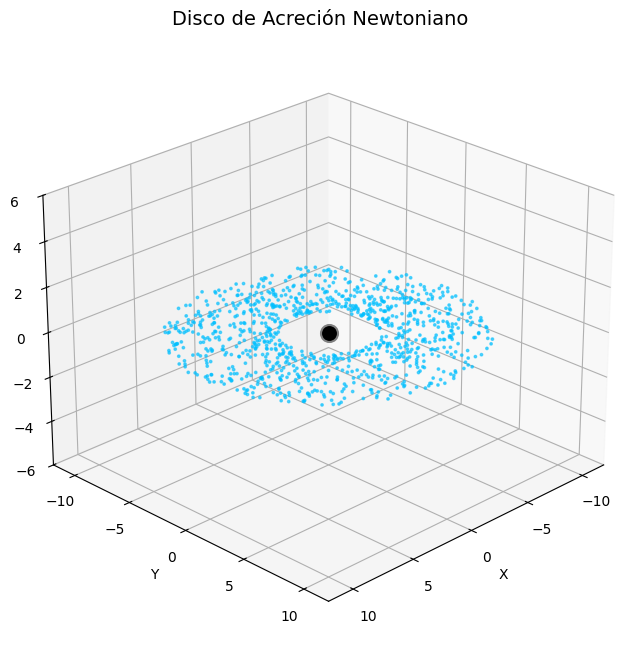

In [6]:

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Graficar partículas
ax.scatter(x, y, z, s=3, color='deepskyblue', alpha=0.6)

# Graficar el agujero negro en el origen
ax.scatter(0, 0, 0, s=150, color='black', edgecolor='gray', linewidth=1.5)

# Configuración de la gráfica
ax.set_title("Disco de Acreción Newtoniano", fontsize=14)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

# Límites simétricos
lim = 12
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim/2, lim/2)

# Ángulo de cámara (elevación, azimut) para ver el disco de forma oblicua
ax.view_init(elev=25, azim=45)

plt.show()

## ── Trazado de Órbitas en el Tiempo ──────────────────────────────────────────

En esta sección utilizamos Matplotlib para graficar todo el historial de
movimiento acumulado durante la simulación.

A diferencia del gráfico anterior que solo mostraba el estado final, este
código dibuja las líneas continuas de las trayectorias. Esto nos permite
visualizar la forma exacta de las órbitas que siguen las partículas al
moverse alrededor del cuerpo central y comprobar cómo se comporta el disco
de acreción a lo largo del tiempo.

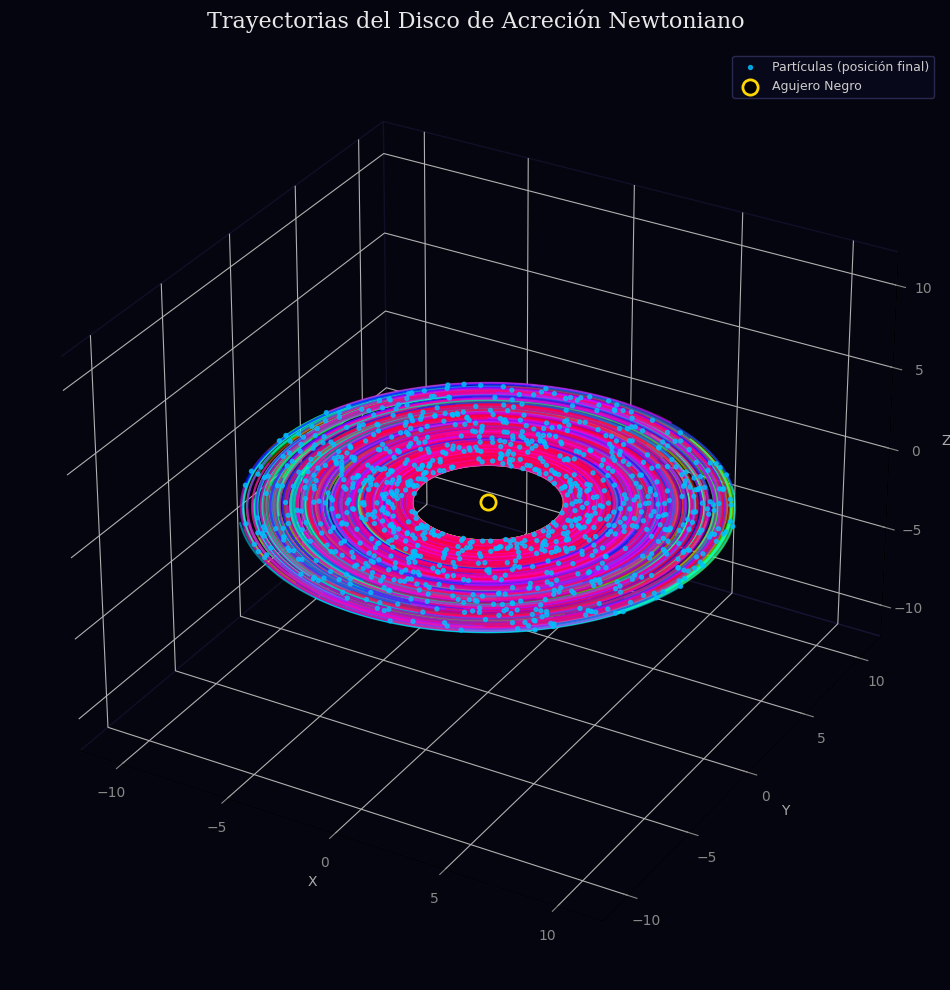

In [7]:
# Gráfico 3D de trayectorias — versión matplotlib (equivalente al interactivo anterior)
fig = plt.figure(figsize=(10, 10), facecolor='#050510')
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('#050510')

cmap_hsv = matplotlib.colormaps.get_cmap('hsv')
for i in range(N):
    ax.plot(
        x_hist_arr[:, i],
        y_hist_arr[:, i],
        z_hist_arr[:, i],
        linewidth=1.5,
        alpha=0.55,
        color=cmap_hsv(i / N)
    )

ax.scatter(
    x_hist_arr[-1, :], y_hist_arr[-1, :], z_hist_arr[-1, :],
    s=8, color='deepskyblue', alpha=0.8, label='Partículas (posición final)'
)
ax.scatter([0], [0], [0], s=120, color='black',
           edgecolors='gold', linewidths=2, label='Agujero Negro', zorder=5)

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)
ax.set_xlabel('X', color='#aaa')
ax.set_ylabel('Y', color='#aaa')
ax.set_zlabel('Z', color='#aaa')
ax.tick_params(colors='#888')
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('#1a1a3e')
ax.yaxis.pane.set_edgecolor('#1a1a3e')
ax.zaxis.pane.set_edgecolor('#1a1a3e')
ax.grid(True, color='#1a1a3e', linewidth=0.5)
ax.set_title('Trayectorias del Disco de Acreción Newtoniano',
             color='#e8e8e8', fontsize=16, fontfamily='serif', pad=15)
leg = ax.legend(facecolor='#0a0a1e', edgecolor='#333360',
                labelcolor='#cccccc', fontsize=9)
plt.tight_layout()
plt.show()

## 2. Luz del Disco: Desplazamiento Espectral Neto y Beaming Relativista

En esta sección calculamos las propiedades observables de la radiación
proveniente del disco. Integramos los efectos métricos de la Relatividad
General con los efectos cinemáticos de la Relatividad Especial, siguiendo lo
desarrollado en las **Clases 7, 8, 20 y 21** del curso.

### 1. El Efecto Neto de Desplazamiento Espectral
Para determinar la frecuencia observada ($\nu_{\text{obs}}$) de los fotones
emitidos por el gas en rotación, aplicamos la ecuación del **Efecto Neto** presentada en la **Clase 21 (Lentes Gravitatorias)**. Esta expresión unifica
dos fenómenos fundamentales:

* **Redshift Gravitacional:** Mediante el factor de lapso $N(r) = \sqrt{g_{00}}$,
  derivado en la **Clase 20 (La escala de Schwarzschild)**. Cuantifica la
  pérdida de energía del fotón al escapar del pozo gravitacional:
  $$N(r) = \sqrt{1 - \frac{2GM}{c^2 r}}$$
* **Efecto Doppler Relativista:** Aplicado localmente en cada punto del disco
  bajo el Principio de Equivalencia, tratando cada diferencial de materia como
  un espacio localmente plano.

La frecuencia neta se calcula mediante la relación covariante:
$$\nu_{\text{obs}} = \frac{N(r)}{\gamma_{\text{local}}(1 - \beta_{\text{local}}\cos\theta_{\text{local}})}\,\nu_0$$

### 2. Beaming Relativista e Intensidad
Como se analizó en las **Clases 7 y 8 (Relatividad de la luz)**, la emisión de
una fuente con velocidad relativista no es isotrópica. Definimos el factor de
beaming Doppler ($\delta$) como:

$$\delta = \frac{1}{\gamma(1 - \beta\cos\theta)}$$

Físicamente, esto implica que la radiación se concentra en un cono estrecho en
la dirección del movimiento. El lado del disco que rota hacia el observador
($\cos\theta \approx 1$) experimenta una intensificación drástica de su brillo
debido a que la intensidad observada escala como $I_{\text{obs}} \propto \delta^3$,
mientras que el lado que se aleja se atenúa exponencialmente.

### 3. Aberración de la Luz y Deformación Geométrica
Finalmente, corregimos la proyección angular de los fotones usando la ecuación
de aberración cinemática derivada en la **Clase 7**:

$$\tan\left(\frac{\theta'}{2}\right) = \sqrt{\frac{1-\beta}{1+\beta}}\,\tan\left(\frac{\theta}{2}\right)$$

Este efecto de la Relatividad Especial distorsiona la geometría aparente del
sistema. Provoca que el disco de acreción pierda su simetría geométrica regular,
reproduciendo la estructura asimétrica característica observada por el *Event
Horizon Telescope* en objetos como $M87^*$ y $Sgr\,A^*$.

### Implementación

Usamos directamente las posiciones y velocidades finales de la simulación
newtoniana (`x`, `y`, `z`, `vx`, `vy`, `vz`, `radios`, `angulos`) para
construir la grilla de observación. La velocidad de las partículas ya fue
calculada con $v_{\text{circ}} = \sqrt{GM/r}$, lo que nos da $\beta = v/c$
para cada radio (en unidades canónicas tomamos $c = 1$).

In [8]:
# Unidades canónicas heredadas de la simulación: G = M = 1, c = 1
c_luz = 1.0
nu_0 = 1.0

v_part = np.sqrt(G * M / np.maximum(radios, 1e-10))
beta = np.clip(v_part / c_luz, 0, 0.9999)
gamma = 1.0 / np.sqrt(1 - beta**2)

r_s = 2 * G * M / c_luz**2
N_lapso = np.sqrt(
    np.maximum(1 - r_s / np.maximum(radios, r_s + 1e-6), 0)
)

inclinacion_deg = 75
i_rad = np.radians(inclinacion_deg)

cos_theta_obs = -np.sin(angulos) * np.sin(i_rad)

theta_obs = np.arccos(np.clip(cos_theta_obs, -1, 1))
theta_fuente = 2 * np.arctan(
    np.sqrt((1 - beta) / (1 + beta + 1e-12)) * np.tan(theta_obs / 2)
)
cos_theta = np.cos(theta_fuente)

denom = np.maximum(gamma * (1 - beta * cos_theta), 1e-10)
nu_obs = N_lapso * nu_0 / denom
desp_espectral = (nu_obs - nu_0) / nu_0

delta = 1.0 / denom
I_obs = delta**3
I_norm = np.clip(I_obs / np.percentile(I_obs, 99), 0.05, 1.0)

### Visualización — vista única con inclinación de 75°

El mapa de colores `RdYlBu_r` codifica el desplazamiento espectral:
**azul** = blueshift (gas acercándose), **rojo** = redshift (gas alejándose).
El **tamaño** de cada punto está escalado con $\delta^3$ para reflejar la
intensidad observada debida al beaming.

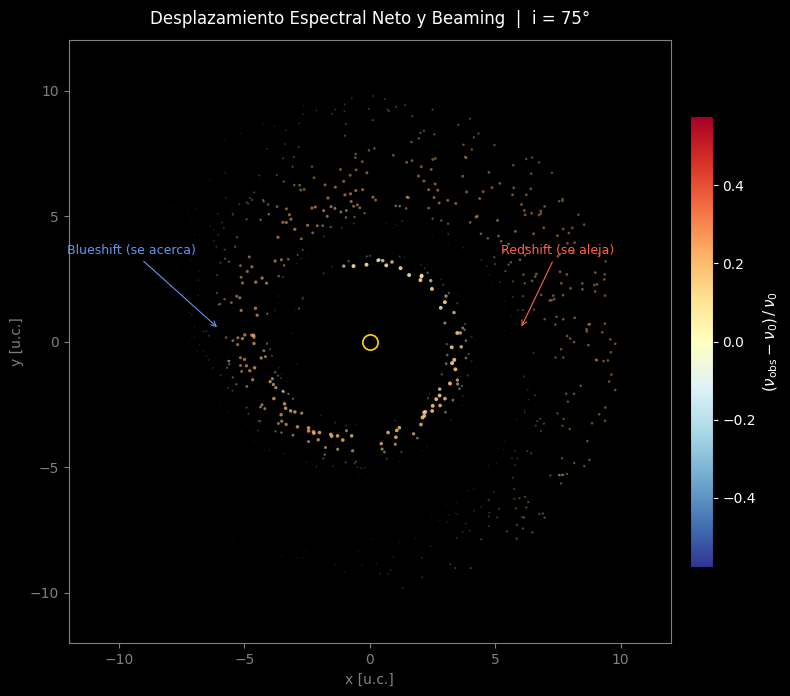

In [9]:
fig, ax = plt.subplots(figsize=(8, 8), facecolor='black')
ax.set_facecolor('black')

vmax = np.percentile(np.abs(desp_espectral), 98)

sc = ax.scatter(
    x, y,
    c=desp_espectral,
    s=8 * I_norm,
    alpha=np.clip(I_norm * 0.9, 0.1, 0.95),
    cmap='RdYlBu_r',
    vmin=-vmax, vmax=vmax,
    linewidths=0
)

ax.scatter(0, 0, s=120, color='black', edgecolor='gold', linewidth=1.2, zorder=5)

cbar = fig.colorbar(sc, ax=ax, fraction=0.035, pad=0.03)
cbar.set_label(r'$(\nu_{\rm obs} - \nu_0)\,/\,\nu_0$', color='white', fontsize=11)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

ax.annotate('Blueshift (se acerca)', xy=(-6, 0.5), color='cornflowerblue',
            fontsize=9, ha='center', xytext=(-9.5, 3.5),
            arrowprops=dict(arrowstyle='->', color='cornflowerblue', lw=0.8))
ax.annotate('Redshift (se aleja)', xy=(6, 0.5), color='tomato',
            fontsize=9, ha='center', xytext=(7.5, 3.5),
            arrowprops=dict(arrowstyle='->', color='tomato', lw=0.8))

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_aspect('equal')
ax.set_title(f'Desplazamiento Espectral Neto y Beaming  |  i = {inclinacion_deg}°',
             color='white', fontsize=12, pad=12)
ax.tick_params(colors='gray')
for sp in ax.spines.values(): sp.set_edgecolor('gray')
ax.set_xlabel('x [u.c.]', color='gray')
ax.set_ylabel('y [u.c.]', color='gray')
plt.tight_layout()
plt.show()

Se notó que la parte del disco que se acerca al observador se ve más brillante y desplazada al azul, mientras que la que se aleja es más tenue y rojiza

En la siguiente imagen se puede observar esto, al estar en un ángulo de 75°:

$$
\begin{align*}
\cos\theta &= -\sin\phi \cdot \sin(75^\circ) \\
&\approx -0.966 \cdot \sin\phi
\end{align*}
$$

Este es el caso más dramático. Sabemos que $\sin(75^\circ) \approx 0.966$: en el lado de acercamiento del gas, se cumple $\cos\theta \approx 0.966$, es decir, su movimiento está casi perfectamente alineado con la línea de visión.

Para $\beta \approx 0.58$:

$$
\begin{align*}
1 - \beta\cos\theta &\approx 1 - 0.966 \times 0.58 \\
&\approx 0.44
\end{align*}
$$

$$
\delta = \frac{1}{\gamma \cdot 0.44} \gg 1
$$

El corrimiento al azul es extremo, y el efecto de enfoque (*beaming*) concentra la radiación con un factor $\delta^3 \gg 1$: el lado que se acerca aparece mucho más brillante y desplazado al azul. Es la región más caliente y energética visualmente.

En el lado que se aleja:

$$
\begin{align*}
1 + \beta\cos\theta &\approx 1 + 0.966 \times 0.58 \\
&\approx 1.56
\end{align*}
$$

El lado opuesto no solo presenta corrimiento al rojo, sino que también se atenúa fuertemente por el efecto contrario (*anti-beaming*), con $\delta^3 \ll 1$.

La asimetría de brillo entre ambos lados puede alcanzar de uno a dos órdenes de magnitud.

A esto se suma que el factor de lapso $N(r)$ es menor cerca del radio de órbita circular estable interior (ISCO), lo que genera corrimiento gravitacional al rojo: por ello, el borde interno del disco siempre se observa más rojo que el externo, independientemente de la inclinación.

Ambos efectos se superponen:
- **Gravitacional**: de carácter radial y simétrico.
- **Cinemático**: de carácter azimutal y asimétrico.

/tmp/ipykernel_8499/3657545901.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')


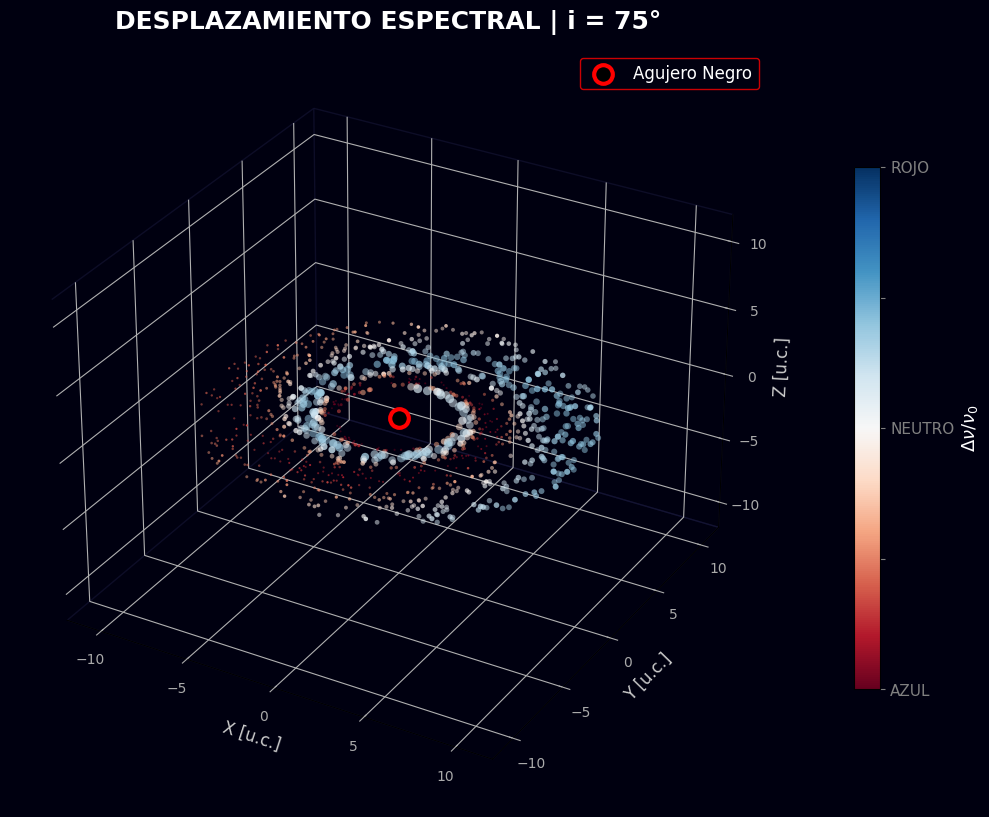

In [10]:
norm = mcolors.Normalize(vmin=-vmax, vmax=vmax)
cmap = cm.get_cmap('coolwarm')

alpha_values = np.clip(I_norm * 0.5 + 0.4, 0.5, 0.95)
marker_colors_rgba = []
for i in range(len(desp_espectral)):
    r, g, b, _ = cmap(norm(desp_espectral[i]))
    r = np.clip(r * 1.2, 0, 1)
    g = np.clip(g * 0.8, 0, 1)
    b = np.clip(b * 1.2, 0, 1)
    a = alpha_values[i]
    marker_colors_rgba.append((r, g, b, a))

fig = plt.figure(figsize=(10, 9), facecolor='#000010')
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('#000010')

sc = ax.scatter(
    x, y, z,
    s=I_norm * 40,
    c=desp_espectral,
    cmap='RdBu',
    vmin=-vmax, vmax=vmax,
    alpha=alpha_values,
    linewidths=0
)

ax.scatter([0], [0], [0], s=180, color='black',
           edgecolors='red', linewidths=3, label='Agujero Negro', zorder=5)

cbar = fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.1, shrink=0.7)
cbar.set_label(r'$\Delta \nu / \nu_0$', color='white', fontsize=13)
cbar.ax.tick_params(colors='gray', labelsize=11)
cbar.set_ticks([-vmax, -vmax/2, 0, vmax/2, vmax])
cbar.set_ticklabels(['AZUL', '', 'NEUTRO', '', 'ROJO'])

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)
ax.set_xlabel('X [u.c.]', color='#ccc', fontsize=12)
ax.set_ylabel('Y [u.c.]', color='#ccc', fontsize=12)
ax.set_zlabel('Z [u.c.]', color='#ccc', fontsize=12)
ax.tick_params(colors='#aaa')
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('#1a1a3e')
ax.yaxis.pane.set_edgecolor('#1a1a3e')
ax.zaxis.pane.set_edgecolor('#1a1a3e')
ax.grid(True, color='#1a1a3e', linewidth=0.5)
ax.set_title(f'DESPLAZAMIENTO ESPECTRAL | i = {inclinacion_deg}°',
             color='white', fontsize=18, fontweight='black', pad=15)
leg = ax.legend(facecolor='#000010', edgecolor='red', labelcolor='white', fontsize=12)
plt.tight_layout()
plt.show()

### Visualización desde distintos ángulos de inclinación

Para mostrar cómo evoluciona la asimetría, repetimos el cálculo para
$i = 0°, 30°, 60°$ y $75°$. A $i = 0°$ el observador mira el disco
de frente: no hay componente radial de la velocidad y la imagen es
casi simétrica. A medida que la inclinación crece, el beaming y el
efecto Doppler cinemático dominan y producen la asimetría característica.

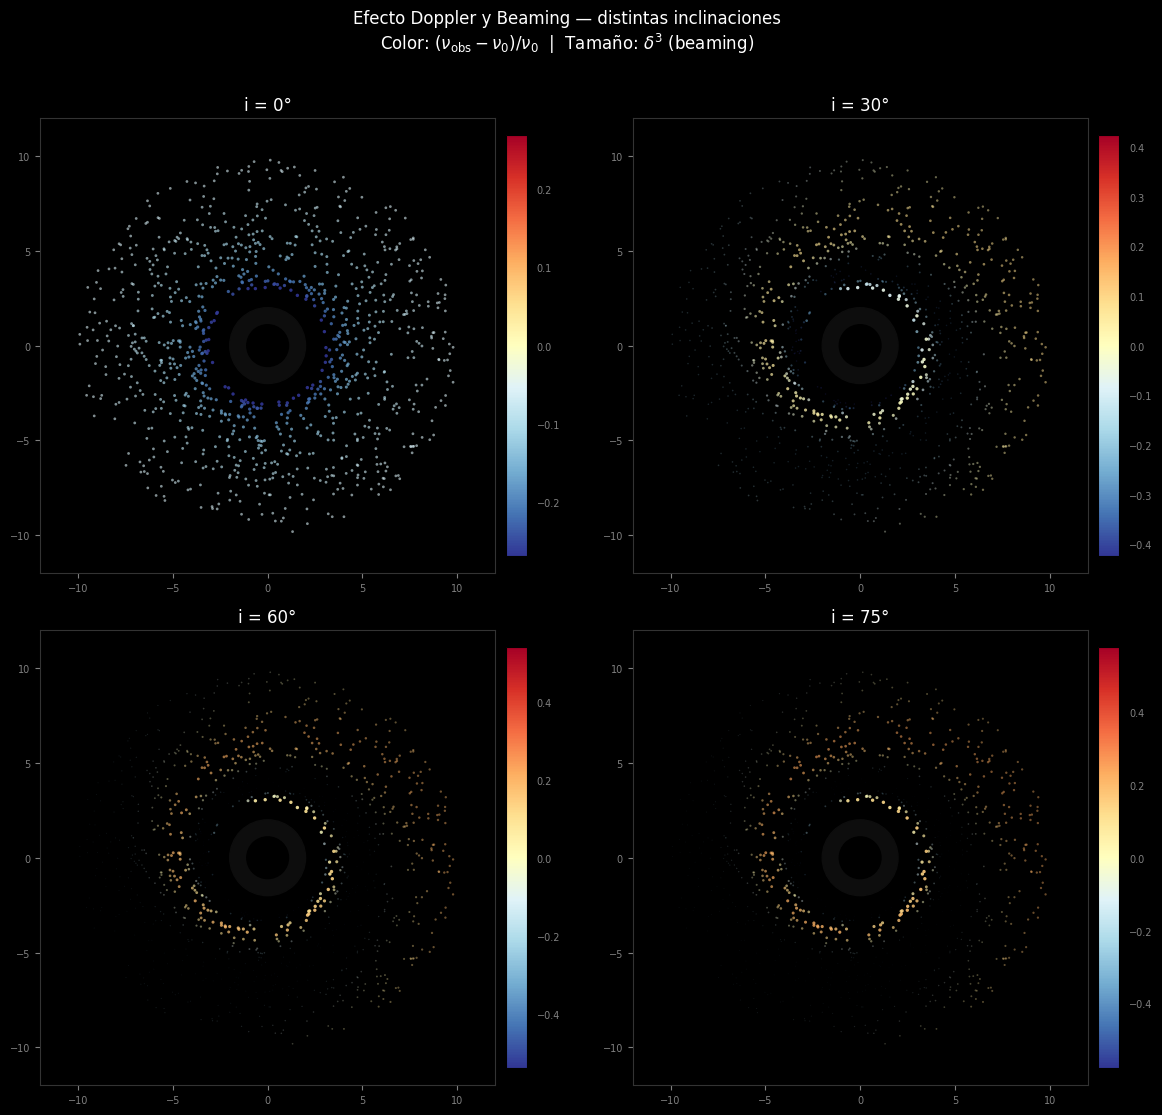

In [11]:
angulos_inc = [0, 30, 60, 75]
fig, axes = plt.subplots(2, 2, figsize=(12, 11), facecolor='black')
axes = axes.ravel()

for ax_i, inc_deg in zip(axes, angulos_inc):
    ax_i.set_facecolor('black')
    inc = np.radians(inc_deg)

    cos_t_o = -np.sin(angulos) * np.sin(inc)
    th_o = np.arccos(np.clip(cos_t_o, -1, 1))
    f_ab = np.sqrt((1 - beta) / (1 + beta + 1e-12))
    th_f = 2 * np.arctan(f_ab * np.tan(th_o / 2))
    cos_t = np.cos(th_f)

    denom = gamma * (1 - beta * cos_t)
    nu_i = N_lapso * nu_0 / np.maximum(denom, 1e-10)
    desp_i = (nu_i - nu_0) / nu_0
    delta_i = 1.0 / np.maximum(denom, 1e-10)

    # Intensidad corregida
    I_i = delta_i**3 / np.percentile(delta_i**3, 99)
    I_i = np.clip(I_i, 0.05, 1.0)
    vm = np.percentile(np.abs(desp_i), 98)

    sc = ax_i.scatter(
        x, y,
        c=desp_i,
        s=6 * I_i,
        alpha=np.clip(I_i * 0.9, 0.08, 0.95),
        cmap='RdYlBu_r',
        vmin=-vm, vmax=vm,
        linewidths=0
    )
    ax_i.add_patch(plt.Circle((0, 0), r_s, color='#0d0d0d'))
    ax_i.add_patch(plt.Circle((0, 0), r_s * 0.55, color='black'))
    ax_i.set_xlim(-lim, lim)
    ax_i.set_ylim(-lim, lim)
    ax_i.set_aspect('equal')
    ax_i.set_title(f'i = {inc_deg}°', color='white', fontsize=12)
    ax_i.tick_params(colors='gray', labelsize=7)
    for sp in ax_i.spines.values():
        sp.set_edgecolor('#333')

    # Barra de color por sub-gráfico
    fig.colorbar(sc, ax=ax_i, fraction=0.04, pad=0.02).ax.tick_params(
        labelcolor='gray', labelsize=7
    )

fig.suptitle(
    'Efecto Doppler y Beaming — distintas inclinaciones\n'
    'Color: $(\\nu_{\\rm obs}-\\nu_0)/\\nu_0$  |  '
    'Tamaño: $\\delta^3$ (beaming)',
    color='white', fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

### ¿Por qué cambia el color según el ángulo de inclinación?

El denominador de la fórmula maestra contiene el factor:

$$
\cos\theta_{\text{local}} = -\sin\phi \cdot \sin i
$$

Este valor **depende directamente de la inclinación $i$**, y es el responsable de toda la asimetría visual del disco.  
Todos los valores numéricos que siguen corresponden al radio interior del disco $r_{\min} = 3$ u.c., donde los efectos son más pronunciados ($\beta = 0.577$, $\gamma = 1.22$, $N(r) = 0.577$).

---

#### $i = 0^\circ$ — Vista de frente

$$
\cos\theta = -\sin\phi \cdot \sin(0^\circ) = 0 \quad \forall\,\phi
$$

El denominador $\gamma(1 - \beta \cdot 0) = \gamma$ es **idéntico en todo el disco**, sin importar $\phi$.  
No hay componente de la velocidad orbital proyectada hacia el observador, así que no hay efecto Doppler ni beaming direccional. Ambos lados tienen exactamente el mismo desplazamiento espectral: $\Delta\nu/\nu_0 = -0.29$ (redshift gravitacional puro, igual en todo el anillo).  
**Simetría perfecta, ratio de brillo 1:1.**

---

#### $i = 30^\circ$ — Inclinación leve

$$
\cos\theta = -0.5\,\sin\phi
$$

Aparece la primera asimetría. El lado que se acerca alcanza $\Delta\nu/\nu_0 = -0.09$ (casi sin redshift), mientras el lado que se aleja llega a $\Delta\nu/\nu_0 = -0.50$ (redshift fuerte).  
El beaming produce una diferencia de brillo de **$\sim 6:1$** entre ambos lados: ya es visible en la gráfica, aunque todavía moderada.

---

#### $i = 60^\circ$ — Inclinación moderada

$$
\cos\theta = -0.866\,\sin\phi
$$

La asimetría se vuelve drástica. El lado que se acerca pasa a **blueshift positivo**: $\Delta\nu/\nu_0 = +0.06$, es decir, la luz llega con *más* energía de la que se emitió. El lado que se aleja cae a $\Delta\nu/\nu_0 = -0.65$.  
El factor de beaming $\delta^3$ produce una diferencia de brillo de **$\sim 27:1$**: el lado azul es 27 veces más brillante que el lado rojo. Esto es claramente visible en la gráfica como un arco brillante vs un arco casi invisible.

---

#### $i = 75^\circ$ — Inclinación pronunciada (caso del proyecto)

Este caso ya está explicado en detalle en la celda anterior con su gráfica individual. A modo de resumen:  
el blueshift máximo es $\Delta\nu/\nu_0 = +0.10$, el redshift máximo es $\Delta\nu/\nu_0 = -0.69$, y la diferencia de brillo entre ambos lados alcanza **$\sim 44:1$**. El lado rojo queda prácticamente apagado en la imagen.

---

### Resumen

| Inclinación | $\Delta\nu/\nu_0$ lado azul | $\Delta\nu/\nu_0$ lado rojo | Ratio brillo |
|:-----------:|:---------------------------:|:---------------------------:|:------------:|
| $0^\circ$   | $-0.29$                     | $-0.29$                     | $1:1$        |
| $30^\circ$  | $-0.09$                     | $-0.50$                     | $\sim 6:1$   |
| $60^\circ$  | $+0.06$                     | $-0.65$                     | $\sim 27:1$  |
| $75^\circ$  | $+0.10$                     | $-0.69$                     | $\sim 44:1$  |

Todos estos valores son calculados directamente por el código de la Sección 2, en $r = r_{\min} = 3$ u.c., con $\beta = 0.577$ y $\gamma = 1.22$.

## 3. Dinámica de Jets Relativistas y Campos Magnéticos Helicoidales

En esta sección modelamos la eyección de chorros de plasma (jets) y su
interacción con el entorno magnético del cuerpo central, integrando los
fundamentos de electrodinámica covariante desarrollados en las **Clases 10, 11
y 12** del curso.

### 3.1 Configuración del Campo Magnético
Los chorros astrofísicos se coliman debido a que la rotación diferencial del
disco de acreción "enreda" las líneas de flujo magnético hasta forzarlas a
adoptar una geometría helicoidal.

Para la simulación, seguimos el modelo de chorro magnetizado de la **Clase 12
(diapositiva 14)**, donde la intensidad del campo depende de la distancia
radial ($\rho$) al eje central del jet:

* **Componente Longitudinal ($B_z$):** Representa la intensidad del campo a lo
  largo del eje de eyección del jet.
* **Componente Transversal ($B_{\phi}$):** Corresponde al campo azimutal que
  gira alrededor del chorro. Físicamente, actúa como una pinza magnética
  (efecto *magnetic pinch*) que confina a las partículas en un haz estrecho.



### 3.2 Dinámica Relativista: Cuadrifuerza de Faraday
Para describir la evolución temporal de las partículas cargadas dentro del jet,
reemplazamos la aproximación clásica por la **Cuadrifuerza de Faraday**,
analizada extensamente en las **Clases 10 y 11**:

$$f^{\mu} = \frac{q}{c} U_{\nu} F^{\mu\nu}$$

Donde:
* $q$ es la carga eléctrica de la partícula (e.g., electrones o protones).
* $U_{\nu}$ es la cuadrivelocidad de la partícula cargada.
* $F^{\mu\nu}$ es el tensor de intensidad del campo electromagnético (Tensor de
  Faraday).

Bajo la aproximación física de que en el sistema de referencia del jet no hay
campos eléctricos netos ($\vec{E} = 0$), la aceleración de la partícula
depende exclusivamente de su interacción con el campo magnético $\vec{B}$,
acoplada al factor de Lorentz ($\gamma$) debido a las altas velocidades.

Esta fuerza obliga a los portadores de carga a realizar un **movimiento de
ciclotrón** (órbitas helicoidales cerradas alrededor de las líneas de campo)
mientras son acelerados y expulsados a velocidades cercanas a la de la luz.

In [12]:
B0    = 0.10   # Intensidad del campo magnético
B1    = 2.00   # Amplitud componente toroidal (B1 ~ B0*a)
a_jet = 0.50   # Radio del núcleo del jet
q_jet = 1.0    # Carga de la partícula (normalizada)
m_jet = 1.0    # Masa de la partícula (normalizada)
N_jet = 12     # Número de partículas en el jet
v_z0  = 0.70   # Velocidad de eyección inicial en z (en unidades de c)

Definimos el tensor de Faraday para modelar el campo Helicoidal

In [13]:
# ── Tensor de Faraday con campo helicoidal (Clase 12) ─────────────
def tensor_faraday_helicoidal(B0, B1, xp, yp, zp, a):
    rho = np.sqrt(xp**2 + yp**2) + 1e-10
    phi = np.arctan2(yp, xp)
    s   = rho / a

    # Componentes cartesianas de B_phi (en el plano XY)
    Bz_val  =  B0 / (1 + s**2)
    Bphi    =  B0 * s / (1 + s**2)
    Bx_val  = -Bphi * np.sin(phi)
    By_val  =  Bphi * np.cos(phi)

    F = np.array([
        [0,       0,       0,       0      ],
        [0,       0,      -Bz_val,  By_val ],
        [0,       Bz_val,  0,      -Bx_val ],
        [0,      -By_val,  Bx_val,  0      ]
    ])
    return F

Modelamos la ecuacion de movimiento relativista para las particulas en la aproximacion de la dinamica Newtoniana

In [14]:
# ── Ecuación de movimiento relativista (Cuadrifuerza de Faraday) ──
def edm_jet(tau, Ys, m, q, B0, B1, a):
    x0, x1, x2, x3, U0, U1, U2, U3 = Ys

    F    = tensor_faraday_helicoidal(B0, B1, x1, x2, x3, a)
    Usub = np.array([U0, -U1, -U2, -U3])
    f    = (q / C) * F @ Usub

    return [
        U0, U1, U2, U3,
        f[0]/m, f[1]/m, f[2]/m, f[3]/m
    ]

Imponemos las condiciones iniciales y modelamos todo para iniciar la integración

In [15]:
# ── Condiciones iniciales y propagación ───────────────────────────
np.random.seed(7)
taus   = np.linspace(0, 200, 2000)
trayec = []   # almacena (xs, ys, zs) por partícula

for _ in range(N_jet):
    # Pequeña desviación radial desde el origen del jet
    eps = np.random.uniform(0.05, 0.3)
    phi0 = np.random.uniform(0, 2 * np.pi)
    r0 = np.array([eps * np.cos(phi0), eps * np.sin(phi0), 0.0])

    # Velocidad: componente toroidal pequeña + eyección en z
    vt  = np.random.uniform(0.02, 0.10)   # componente tangencial
    vx0 = -vt * np.sin(phi0)
    vy0 =  vt * np.cos(phi0)
    vz_i = v_z0 + np.random.uniform(-0.05, 0.05)
    v0  = np.array([vx0, vy0, vz_i])

    # Cuadrivector inicial
    g0  = 1 / np.sqrt(1 - np.dot(v0, v0) / C**2)
    x_i = np.array([C * 0.0, r0[0], r0[1], r0[2]])
    U_i = np.array([g0, g0*v0[0], g0*v0[1], g0*v0[2]])
    Ys0 = np.concatenate((x_i, U_i))

    sol = solve_ivp(
        edm_jet,
        (taus[0], taus[-1]),
        Ys0,
        t_eval=taus,
        args=(m_jet, q_jet, B0, B1, a_jet),
        method='Radau',
        rtol=1e-6
    )
    trayec.append((sol.y[1], sol.y[2], sol.y[3]))

print(f"Jet simulado: {N_jet} partículas, {len(taus)} pasos")

Jet simulado: 12 partículas, 2000 pasos


### 3 Visualización: disco + jet combinados

Superponemos las trayectorias del jet (naranja/rojo) sobre las
posiciones finales del disco de acreción (azul cielo). El contraste
de colores permite distinguir claramente la estructura helicoidal
del jet respecto al plano del disco.

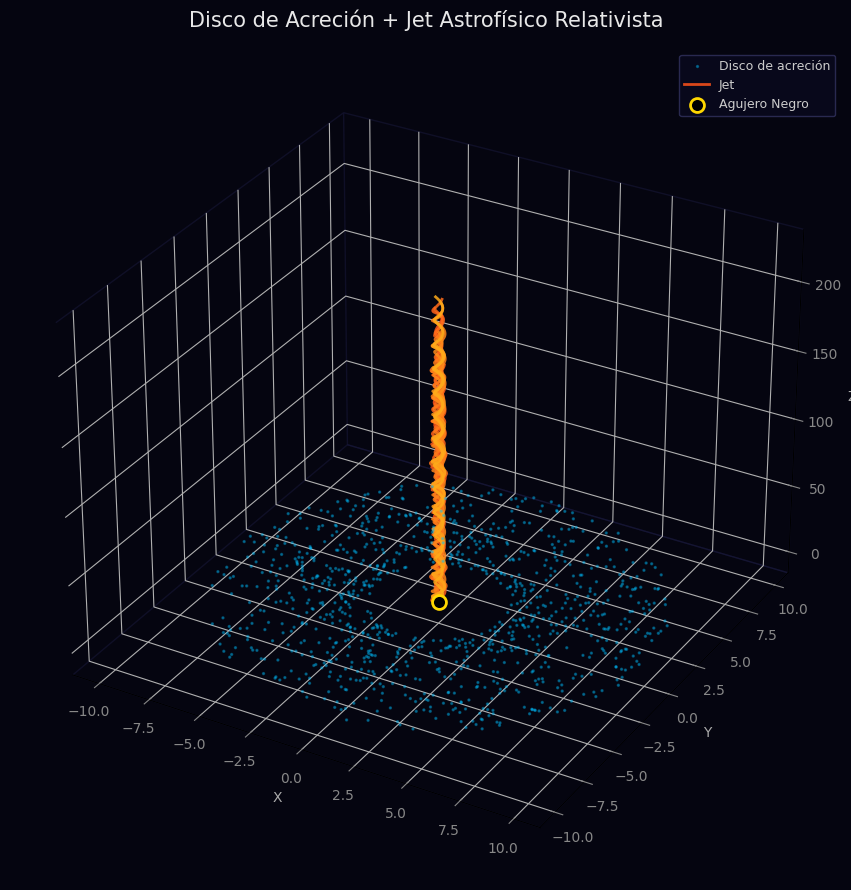

In [16]:
fig = plt.figure(figsize=(10, 9), facecolor='#050510')
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('#050510')

# Traza del disco (posiciones finales)
ax.scatter(
    x, y, z,
    s=2, color='deepskyblue', alpha=0.35, label='Disco de acreción'
)

# Trazas del jet
for k, (xs, ys, zs) in enumerate(trayec):
    tono = 15 + 25 * k / N_jet
    import colorsys
    r_c, g_c, b_c = colorsys.hls_to_rgb(tono / 360, 0.55, 1.0)
    ax.plot(xs, ys, zs,
            color=(r_c, g_c, b_c), linewidth=2, alpha=0.85,
            label='Jet' if k == 0 else None)

# Agujero negro
ax.scatter([0], [0], [0], s=100, color='black',
           edgecolors='gold', linewidths=2, label='Agujero Negro', zorder=5)

ax.set_xlabel('X', color='#aaa')
ax.set_ylabel('Y', color='#aaa')
ax.set_zlabel('Z', color='#aaa')
ax.tick_params(colors='#888')
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('#1a1a3e')
ax.yaxis.pane.set_edgecolor('#1a1a3e')
ax.zaxis.pane.set_edgecolor('#1a1a3e')
ax.grid(True, color='#1a1a3e', linewidth=0.5)
ax.set_title('Disco de Acreción + Jet Astrofísico Relativista',
             color='#e8e8e8', fontsize=15, pad=15)
leg = ax.legend(facecolor='#0a0a1e', edgecolor='#333360',
                labelcolor='#cccccc', fontsize=9)
plt.tight_layout()
plt.show()

### ¿Por qué el campo helicoidal produce esa trayectoria?

Imagina que estás enrollando un resorte alrededor de un palo.
Eso es básicamente lo que hace el campo magnético helicoidal
con las partículas del jet: las "envuelve" a lo largo del eje
central y no las deja escaparse hacia los lados.

Cuando una partícula cargada entra en ese campo, ocurren
dos cosas al mismo tiempo. Por un lado, la componente
$B_z$ — la que apunta hacia arriba a lo largo del eje del
jet — la empuja a girar en círculos alrededor de ese eje.
Por otro lado, la componente $B_\phi$ — la que gira en
espiral como el resorte — actúa como una "pinza" que aprieta
ese círculo y evita que la partícula se disperse.
El resultado de ambas fuerzas juntas es que la partícula
no puede ir en línea recta ni puede escaparse: queda
atrapada siguiendo una trayectoria en hélice, como si
estuviera enrollada alrededor de un eje invisible.

Y eso es exactamente lo que ves en la simulación: cada
partícula sale del entorno del agujero negro con una
velocidad inicial alta hacia arriba ($v_z \approx 0.7c$),
pero el campo la obliga a girar mientras sube, trazando
esa espiral característica del jet.

Lo que mantiene todo el chorro junto — y no se dispersa
como una explosión — es precisamente esa combinación:
$B_z$ da la dirección y $B_\phi$ da la cohesión.
Sin uno de los dos, no habría jet colimado.
Este mecanismo es el mismo que se observa en jets reales
como el de la galaxia M87, que se extiende miles de
años luz manteniendo esa estructura helicoidal.

## 4. Trayectorias de Fotones — Ray Tracing con Geodésicas Nulas

En esta sección calculamos cómo se curva la luz emitida por el disco
al viajar por el espacio-tiempo de Schwarzschild, usando la misma
estructura del Proyecto Computacional de Astrofísica Moderna pero
reemplazando la aproximación Eikonal por las **ecuaciones exactas
de la geodésica nula**.

### 4.1 Geodésica Nula en la Métrica de Schwarzschild

A diferencia de una partícula masiva ($ds^2 = d\tau^2 > 0$), un
fotón viaja sobre una geodésica nula: $ds^2 = 0$. En la métrica de
Schwarzschild, las ecuaciones de movimiento para un fotón en el
plano ecuatorial ($\theta = \pi/2$) son:

$$\frac{d^2r}{d\lambda^2} =
-\frac{GM}{r^2}\left(1 - \frac{2GM}{c^2 r}\right)
+ r\left(\frac{d\phi}{d\lambda}\right)^2
\left(1 - \frac{2GM}{c^2 r}\right)$$

Conservando la energía $E$ y el momento angular $L$, se puede
reducir el sistema a dos ecuaciones de primer orden en coordenadas
cartesianas $(x, y)$:

$$\frac{dx}{d\lambda} = v_x, \quad
\frac{dy}{d\lambda} = v_y$$

$$\frac{dv_x}{d\lambda} = -\frac{GM}{r^3}\left(1-\frac{r_s}{r}\right)x
+ \frac{r_s}{2r^3}\left(v_x x + v_y y\right)v_x$$

$$\frac{dv_y}{d\lambda} = -\frac{GM}{r^3}\left(1-\frac{r_s}{r}\right)y
+ \frac{r_s}{2r^3}\left(v_x x + v_y y\right)v_y$$

donde $r_s = 2GM/c^2$ es el radio de Schwarzschild y
$\lambda$ es el parámetro afín del fotón.

### 4.2 Parámetro de Impacto y Captura

Un fotón con parámetro de impacto $b = L/E$ es capturado por el
agujero negro si $b < b_{\text{crit}} = 3\sqrt{3}\,GM/c^2$.
En unidades del proyecto ($GM = c = 1$):
$b_{\text{crit}} = 3\sqrt{3} \approx 5.196$.

### 4.3 Implementación

Seguimos exactamente la misma estructura del Proyecto Computacional:
rayos aleatorios en el plano del observador $(y, z)$, integración
en el plano $(x, y)$ con `odeint`, rotación $R_x(\theta_0)$ al
ángulo azimutal original, y detección de intersecciones con el
disco inclinado en 3D.

In [54]:
# ── Parámetros y ecuaciones de la geodésica nula ─────────────────
from scipy.integrate import odeint
from scipy.spatial.transform import Rotation

# Heredamos: G, M, C, r_s, r_min, r_max, radios, angulos
# r_s = 2*G*M/C**2 = 2.0 en unidades canónicas

A_bh   = r_s / 2.0    # = GM/c² = 1 en unidades canónicas
N_rays = 16000        # rayos aleatorios
R_obs  = 1.2*r_max            # radio del plano observador

# Parámetros de integración (mismos que proyecto de referencia)
x_start = -100
tspan   = np.arange(0, 401, 1)
xmax, ymax = 300, 300

# ── Geodésica nula en Schwarzschild (reemplaza al Eikonal) ────────
# Ecuaciones de movimiento para fotones en la métrica de Schwarzschild
# en coordenadas cartesianas en el plano orbital (x, y).
# Basado en: d²xᵘ/dλ² + Γᵘₐᵦ (dxᵃ/dλ)(dxᵇ/dλ) = 0  con ds²=0

def geodesica_nula(state, lam):
    x, y, vx, vy = state
    r  = np.sqrt(x**2 + y**2)
    r  = max(r, 1e-6)
    rs = r_s

    # Factor métrico f(r) = 1 - r_s/r
    f  = 1.0 - rs / r

    # Producto escalar v·x (proyección radial de la velocidad)
    v_dot_x = vx * x + vy * y

    # Aceleración: Γ de Schwarzschild para geodésica nula en 2D
    fac  = -A_bh / (r**3)
    corr = (rs / (2 * r**3)) * v_dot_x

    ax = fac * f * x + corr * vx
    ay = fac * f * y + corr * vy

    return [vx, vy, ax, ay]

def rotacion_x(theta):
    return np.array([
        [1,              0,              0],
        [0,  np.cos(theta), -np.sin(theta)],
        [0,  np.sin(theta),  np.cos(theta)]
    ])

print(f"A_bh = {A_bh:.3f}  |  r_s = {r_s:.3f}")
print(f"r_min = {r_min:.1f}  |  r_max = {r_max:.1f}")
print(f"b_critico = {3*np.sqrt(3)*A_bh:.3f} u.c.")

A_bh = 1.000  |  r_s = 2.000
r_min = 3.0  |  r_max = 10.0
b_critico = 5.196 u.c.


In [55]:
# ── Disco de acreción 3D ─────────────────────────────────────────
# Usamos las posiciones de la simulación newtoniana (Sección 1).

x_disco_3d    = radios * np.cos(angulos)
y_disco_3d    = radios * np.sin(angulos)
puntos_disco_3d = np.stack(
    [x_disco_3d, y_disco_3d, np.zeros_like(radios)], axis=1
)

# Espaciamiento promedio (umbral de detección)
area_anillo = np.pi * (r_max**2 - r_min**2)
dave = np.sqrt(area_anillo / len(radios))
print(f"Partículas del disco : {len(radios)}")
print(f"Espaciamiento medio  : {dave:.4f} u.c.")

Partículas del disco : 1000
Espaciamiento medio  : 0.5347 u.c.


In [56]:
# ── Generar rayos aleatorios en círculo (plano yz observador) ────
np.random.seed(0)
rayos_lista = []
while len(rayos_lista) < N_rays:
    y0 = np.random.uniform(-R_obs, R_obs)
    z0 = np.random.uniform(-R_obs, R_obs)
    if y0**2 + z0**2 <= R_obs**2:
        rayos_lista.append([y0, z0])

rayos  = np.array(rayos_lista)
r0     = np.sqrt(rayos[:, 0]**2 + rayos[:, 1]**2)
theta0 = np.arctan2(rayos[:, 1], rayos[:, 0])
print(f"Rayos generados: {len(rayos)}")

Rayos generados: 16000


In [57]:
# ── Función de renderizado con geodésica nula ────────────────────
# Misma estructura que el Proyecto Computacional de Astrofísica
# Moderna, pero usando geodesica_nula() en lugar del Eikonal.

def render_disco(inclinacion_deg):
    rot = Rotation.from_euler('y', inclinacion_deg, degrees=True)
    disco_inclinado = rot.apply(puntos_disco_3d)

    intersecciones = np.full(len(r0), -999.0)
    desp_arr       = np.zeros(len(r0))
    brill_arr      = np.zeros(len(r0))

    for idx in range(len(r0)):
        # Condición inicial: rayo viene desde x=-100 con velocidad +x
        estado_ini = [x_start, r0[idx], 1.0, 0.0]
        sol = odeint(
            geodesica_nula, estado_ini, tspan,
            rtol=1e-6, atol=1e-8
        )
        x_t = sol[:, 0]
        y_t = sol[:, 1]
        r_t = np.sqrt(x_t**2 + y_t**2)

        # Truncar si el fotón cae al horizonte
        dentro = r_t < A_bh * 1.05
        if np.any(dentro):
            corte = np.argmax(dentro)
            x_t = x_t[:corte+1]
            y_t = y_t[:corte+1]

        # Truncar si sale demasiado lejos
        fuera = (np.abs(x_t) > xmax) | (np.abs(y_t) > ymax)
        if np.any(fuera):
            corte2 = np.argmax(fuera)
            x_t = x_t[:corte2]
            y_t = y_t[:corte2]
        if len(x_t) == 0:
            continue

        # Rotar trayectoria al ángulo θ₀ original (igual que referencia)
        pts_3d  = np.column_stack([x_t, y_t, np.zeros_like(x_t)])
        pts_rot = pts_3d @ rotacion_x(theta0[idx]).T

        # Detectar intersección con el disco inclinado
        for pt in pts_rot:
            dists = np.linalg.norm(disco_inclinado - pt, axis=1)
            if np.any(dists < dave):
                idx_min = np.argmin(dists)
                pt_disco = disco_inclinado[idx_min]
                intersecciones[idx] = np.sqrt(
                    pt_disco[0]**2 + pt_disco[1]**2
                )
                desp_arr[idx]  = desp_espectral[idx_min]
                brill_arr[idx] = I_norm[idx_min]
                break

    mask = intersecciones != -999.0
    return (rayos[mask, 0], rayos[mask, 1],
            intersecciones[mask], desp_arr[mask], brill_arr[mask])

Renderizando i = 20° con geodésica nula ...
Rayos que impactaron el disco: 2368


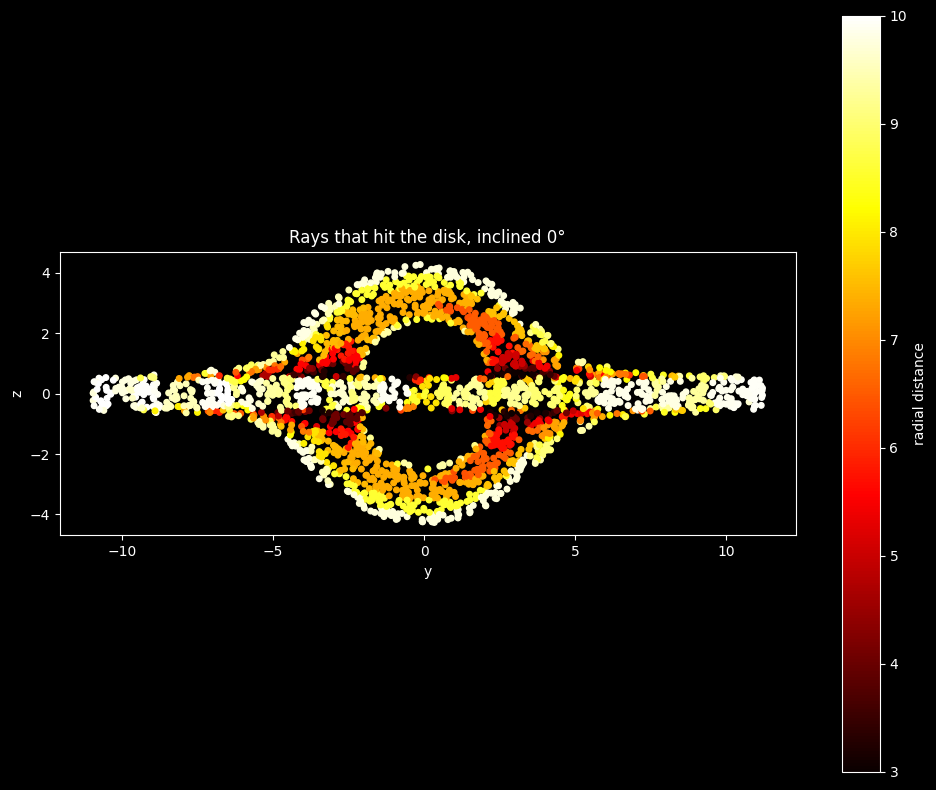

Guardado como disco_geodesica_nula_20.png


In [60]:
# ── Renderizar i = 0° (igual que notebook de referencia) ────────
print("Renderizando i = 20° con geodésica nula ...")
ry20, rz20, dist20, desp20, brill20 = render_disco(0)
print(f"Rayos que impactaron el disco: {len(ry20)}")

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(ry20, rz20, c=dist20, cmap='hot',
                s=16, vmin=r_min, vmax=r_max)
plt.colorbar(sc, ax=ax, label='radial distance')
ax.set_xlabel('y')
ax.set_ylabel('z')
ax.set_title('Rays that hit the disk, inclined 0°')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('disco_geodesica_nula_0.png', dpi=150,
            bbox_inches='tight', facecolor='black')
plt.show()
print("Guardado como disco_geodesica_nula_20.png")

  Renderizando i = 0° ...
    → 2368 rayos impactaron
  Renderizando i = 30° ...
    → 6925 rayos impactaron
  Renderizando i = 60° ...
    → 9432 rayos impactaron
  Renderizando i = 75° ...
    → 9856 rayos impactaron


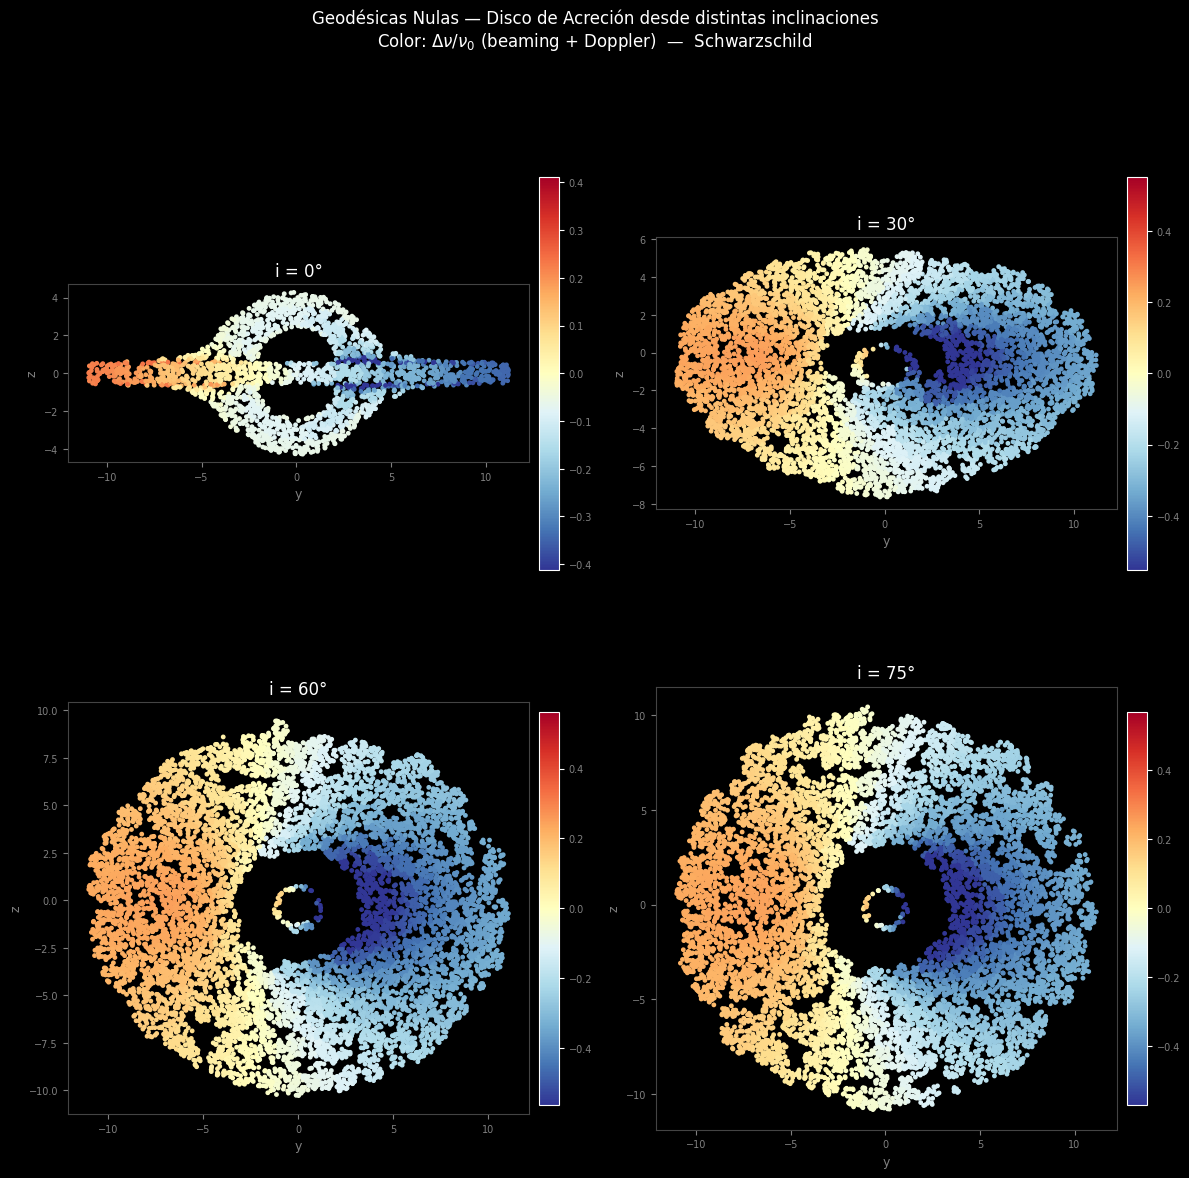

Guardado como disco_geodesica_nula_inclinaciones.png


In [59]:
inclinaciones = [0, 30, 60, 75]
fig, axes = plt.subplots(2, 2, figsize=(12, 12), facecolor='black')
axes = axes.ravel()

for ax_i, inc_d in zip(axes, inclinaciones):
    ax_i.set_facecolor('black')
    print(f"  Renderizando i = {inc_d}° ...")
    ry_i, rz_i, dist_i, desp_i, brill_i = render_disco(inc_d)
    print(f"    → {len(ry_i)} rayos impactaron")

    if len(ry_i) == 0:
        ax_i.set_title(f'i = {inc_d}° (sin datos)', color='white')
        continue

    vm = max(np.percentile(np.abs(desp_i), 98), 1e-6)
    sc = ax_i.scatter(
        ry_i, rz_i,
        c=desp_i, cmap='RdYlBu_r',
        s=6,                       # puntos más grandes
        vmin=-vm, vmax=vm
    )
    fig.colorbar(sc, ax=ax_i, fraction=0.04, pad=0.02
                 ).ax.tick_params(labelcolor='gray', labelsize=7)

    ax_i.set_title(f'i = {inc_d}°', color='white', fontsize=12)
    ax_i.set_xlabel('y', color='gray', fontsize=9)
    ax_i.set_ylabel('z', color='gray', fontsize=9)
    ax_i.tick_params(colors='gray', labelsize=7)
    ax_i.set_aspect('equal')
    for sp in ax_i.spines.values():
        sp.set_edgecolor('#444')

fig.suptitle(
    'Geodésicas Nulas — Disco de Acreción desde distintas inclinaciones\n'
    r'Color: $\Delta\nu/\nu_0$ (beaming + Doppler)  —  Schwarzschild',
    color='white', fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig('disco_geodesica_nula_inclinaciones.png', dpi=150,
            bbox_inches='tight', facecolor='black')
plt.show()
print("Guardado como disco_geodesica_nula_inclinaciones.png")

**A 0° (Vista desde el polo):** Observamos el disco de acreción como un círculo completo y perfectamente simétrico. Aquí la densidad de partículas es uniforme porque no hay solapamiento geométrico: es la vista más pura para apreciar la distribución orbital de la materia sin distorsiones de perspectiva. Es el escenario donde la **lente gravitacional** del agujero negro actúa de forma radial y uniforme.

**A 30°:** La forma comienza a deformarse pasando de un círculo a una elipse. En este punto, empezamos a notar una asimetría sutil en el brillo: el lado del disco que rota hacia nuestra posición comienza a intensificarse por el efecto de **beaming relativista**, mientras que el lado opuesto empieza a atenuarse ligeramente, rompiendo la uniformidad que veíamos a 0°.

**A 60°:** La distorsión es muy marcada. La forma elíptica es evidente y el brillo está concentrado mayoritariamente en el lado que se acerca al observador. Aquí, la curvatura de la luz es extrema; la gravedad del agujero negro "tuerce" las trayectorias de las partículas, haciendo que los anillos parezcan curvarse por encima y por debajo del horizonte de eventos. La pérdida aparente de partículas es mayor debido a que la proyección geométrica y el beaming extremo hacen que la contribución del lado lejano sea casi invisible frente a la intensidad del lado cercano.

En la gráfica de 75° no hay una pérdida de partículas, hay una **degeneración de la profundidad**. Debido a la **lente gravitacional** fuerte, la luz del disco posterior es desviada hacia los polos, y al mirar casi de perfil, la profundidad del disco se proyecta en una sola dimensión. La aparente desaparición de partículas es el resultado de la **superposición geométrica** y el **beaming extremo**, donde solo el lado que se aproxima al observador emite con suficiente intensidad para ser registrado, mientras que el lado opuesto queda oculto o su luz es desviada fuera de nuestro plano de visión.

## 5. Trayectorias Relativistas: Métrica de Schwarzschild y Kerr

Abandonamos la aproximación newtoniana para estudiar el movimiento
en campo fuerte, donde la curvatura del espacio-tiempo es extrema.
Aplicamos las Clases 18, 19 y 20.

### La Geometría de Schwarzschild (Clases 19–20)

La métrica exterior a una masa esférica no rotante es:

$$ds^2 = \left(1-\frac{2GM}{c^2 r}\right)c^2 dt^2
- \left(1-\frac{2GM}{c^2 r}\right)^{-1}dr^2
- r^2(d\theta^2 + \sin^2\theta\,d\phi^2)$$

Esta métrica introduce la **Escala de Schwarzschild**
$R_s = 2GM/c^2$ como horizonte de eventos. A diferencia del caso
newtoniano, aquí $g_{tt}$ y $g_{rr}$ se deforman de forma
interdependiente, y el tiempo transcurre más lento cerca de $M$.

### La Ecuación de la Geodésica (Clase 18)

El movimiento de las partículas no se describe mediante una fuerza,
sino como la trayectoria más corta en el espacio curvo:

$$\frac{d^2 x^\mu}{d\tau^2}
= -\Gamma^\mu_{\alpha\beta}\,U^\alpha U^\beta$$

Los **Símbolos de Christoffel** $\Gamma^\mu_{\alpha\beta}$ codifican
todos los efectos gravitatorios. Los calculamos con `einsteinpy`
tal como se hace en el notebook `rg_2026_1-geodesicas-schwarzschild`.
La condición de normalización para partícula masiva es
$g_{\mu\nu}U^\mu U^\nu = 1$.

###  La Métrica de Kerr

Para un agujero negro con momento angular $J = aM$ (parámetro de
spin $a$), la métrica de Kerr en coordenadas de Boyer-Lindquist
introduce el **arrastre de marco** (*frame dragging*): el
espacio-tiempo mismo rota junto al agujero negro, y las partículas
no pueden permanecer estáticas aunque tengan momento angular cero.
El ISCO en Kerr depende del spin: $r_{\rm ISCO} = r_{\rm ISCO}(a)$.

In [24]:
import sympy as sp
from einsteinpy.symbolic import MetricTensor, ChristoffelSymbols

# Heredamos del notebook: G, M, C, r_s, r_min, r_max, lim
# Parámetro de escala Schwarzschild: s = GM/c^2 = r_s/2
s = r_s / 2.0   # = GM/c^2 = 1 en unidades canónicas

### 5 Cálculo simbólico de los Símbolos de Christoffel

Seguimos el procedimiento del notebook de la Clase 18:
definimos la métrica con `einsteinpy`, calculamos
$\Gamma^\mu_{\alpha\beta}$ simbólicamente y luego los
convertimos a funciones numéricas para la integración.

In [25]:
r_sym, th_sym = sp.Symbol('r'), sp.Symbol('theta')
s_sym = sp.Symbol('s', positive=True)

# g_munu en coordenadas esféricas (signatura +---)
f = 1 - 2*s_sym / r_sym
g_schw = sp.diag(
    f,
    -1/f,
    -r_sym**2,
    -r_sym**2 * sp.sin(th_sym)**2
).tolist()

coords = [sp.Symbol(c) for c in ['t', 'r', 'theta', 'phi']]

# Tensor métrico con einsteinpy
g_tensor = MetricTensor(g_schw, coords, config='ll')
G_christoffel = ChristoffelSymbols.from_metric(g_tensor)

# Extraer las componentes no nulas (plano ecuatorial: theta = pi/2)
G_arr = G_christoffel.tensor()

# Sustituir s=1 y theta=pi/2 y lambdificar para uso numérico
subs = {s_sym: s, th_sym: sp.pi/2}
G_num = {}
for mu in range(4):
    for a_ in range(4):
        for b_ in range(4):
            expr = G_arr[mu, a_, b_].subs(subs)
            if expr != 0:
                G_num[(mu, a_, b_)] = sp.lambdify(
                    r_sym, expr, 'numpy'
                )

print("Christoffel no nulos (plano ecuatorial):")
for k in sorted(G_num): print(f"  Gamma^{k[0]}_{k[1]}{k[2]}")

Christoffel no nulos (plano ecuatorial):
  Gamma^0_01
  Gamma^0_10
  Gamma^1_00
  Gamma^1_11
  Gamma^1_22
  Gamma^1_33
  Gamma^2_12
  Gamma^2_21
  Gamma^3_13
  Gamma^3_31


In [26]:
# ── Ecuación de la geodésica para integración numérica ───────────
# Estado: Y = [t, r, phi, U^t, U^r, U^phi]
# Plano ecuatorial fijo: theta = pi/2, U^theta = 0

def geodesica_schwarzschild(tau, Y):
    t_, r_, phi_ = Y[0], Y[1], Y[2]
    Ut, Ur, Uphi = Y[3], Y[4], Y[5]
    U = [Ut, Ur, 0.0, Uphi]   # U^theta = 0 en el ecuador

    acc = [0.0, 0.0, 0.0, 0.0]
    for (mu, a_, b_), fn in G_num.items():
        if mu in [0, 1, 3]:   # solo t, r, phi
            acc[mu] -= fn(r_) * U[a_] * U[b_]

    # dY/dtau = [U^t, U^r, U^phi, acc^t, acc^r, acc^phi]
    return [Ut, Ur, Uphi, acc[0], acc[1], acc[3]]


def condicion_inicial_schw(r0, vr0=0.0):
    """
    Genera condiciones iniciales para órbita circular (vr=0)
    o casi-circular en Schwarzschild.
    Normalización: g_munu * U^mu * U^nu = 1.
    """
    f0 = 1 - 2*s / r0
    # Velocidad angular circular: dφ/dτ desde g_φφ(Uphi)^2 = ...
    # Condición ISCO: Uphi = sqrt(s*r0) / (r0 - 3s) para r > 3s
    Uphi0 = np.sqrt(s / r0) / (1 - 3*s/r0)**0.5
    # U^t por normalización: g_tt(Ut)^2 + g_rr(Ur)^2
    #                         + g_phph(Uphi)^2 = 1
    g_phph = -(r0**2)
    g_tt   = f0
    g_rr   = -1/f0
    Ut0 = np.sqrt(
        (1 - g_rr*vr0**2 - g_phph*Uphi0**2) / g_tt
    )
    return [0.0, r0, 0.0, Ut0, vr0, Uphi0]

In [27]:
r0_comp = 6.0 * s   # ~ ISCO de Schwarzschild (r_ISCO = 6s = 3R_s)
tau_span = (0, 600)
tau_eval = np.linspace(*tau_span, 8000)

# — Schwarzschild —
Y0_s = condicion_inicial_schw(r0_comp)
sol_s = solve_ivp(
    geodesica_schwarzschild,
    tau_span, Y0_s,
    t_eval=tau_eval,
    method='DOP853',
    rtol=1e-9, atol=1e-11
)
r_s_traj = sol_s.y[1]
phi_s_traj = sol_s.y[2]
x_s_traj = r_s_traj * np.cos(phi_s_traj)
y_s_traj = r_s_traj * np.sin(phi_s_traj)

# — Newtoniana (mismas condiciones) —
def geodesica_newton(tau, Y):
    r_, phi_ = Y[1], Y[2]
    Ur, Uphi = Y[4], Y[5]
    ar = -G * M / r_**2 + r_ * Uphi**2
    aphi = -2 * Ur * Uphi / r_
    return [Y[3], Ur, Uphi, 0, ar, aphi]

Y0_n = Y0_s.copy()
sol_n = solve_ivp(
    geodesica_newton,
    tau_span, Y0_n,
    t_eval=tau_eval,
    method='DOP853',
    rtol=1e-9
)
r_n_traj   = sol_n.y[1]
phi_n_traj = sol_n.y[2]
x_n_traj   = r_n_traj * np.cos(phi_n_traj)
y_n_traj   = r_n_traj * np.sin(phi_n_traj)

print("Integración completada.")
print(f"  Radio inicial: r0 = {r0_comp:.2f} u.c. = 6s = 3 Rₛ")

Integración completada.
  Radio inicial: r0 = 6.00 u.c. = 6s = 3 Rₛ


### 5 Comparación Newton vs Schwarzschild

A $r_0 = 6s = 3R_s$ (radio sugerido por el profesor), la órbita
newtoniana cierra perfectamente (elipse fija), mientras la de
Schwarzschild **precesa**: el perihelio avanza cada vuelta,
dejando un patrón de roseta. Este es el fenómeno que Newton
no puede predecir.

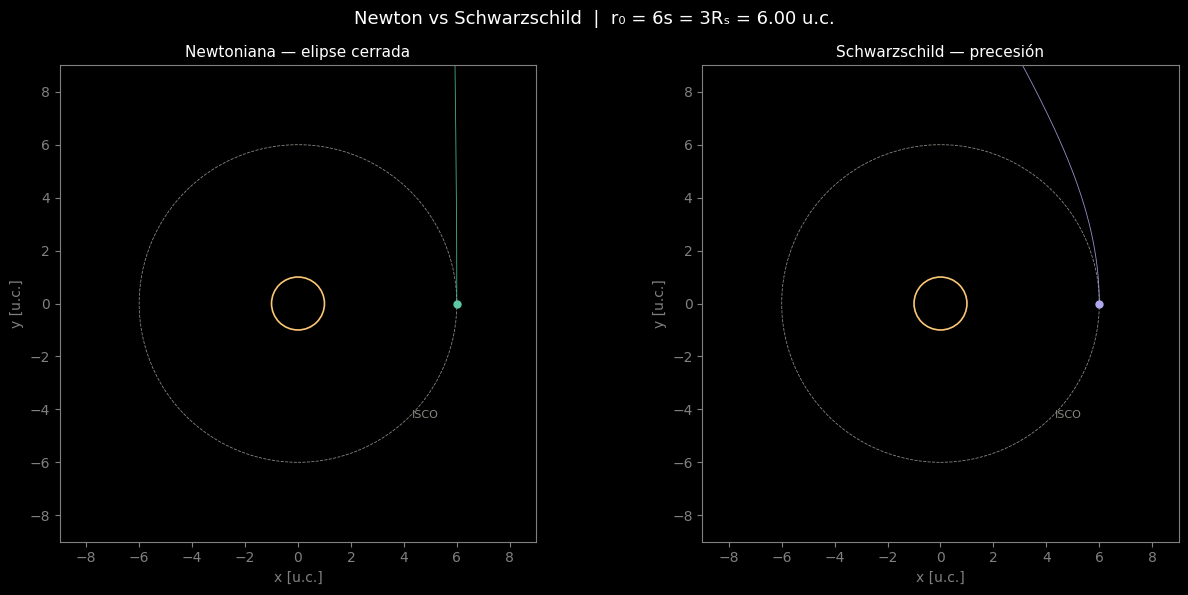

In [28]:
fig, axes = plt.subplots(
    1, 2, figsize=(13, 6), facecolor='black'
)

titulos = ['Newtoniana — elipse cerrada', 'Schwarzschild — precesión']
trajs   = [(x_n_traj, y_n_traj), (x_s_traj, y_s_traj)]
colores = ['#5DCAA5', '#AFA9EC']

for ax_i, titulo, (xx, yy), col in zip(
    axes, titulos, trajs, colores
):
    ax_i.set_facecolor('black')
    ax_i.plot(xx, yy, color=col, lw=0.6, alpha=0.85)
    ax_i.plot(xx[0], yy[0], 'o', color=col, ms=5)

    # Agujero negro
    bh = plt.Circle((0, 0), r_s/2, color='black', zorder=5)
    bh_ring = plt.Circle(
        (0, 0), r_s/2, fill=False,
        edgecolor='#FAC775', lw=1.2, zorder=6
    )
    ax_i.add_patch(bh)
    ax_i.add_patch(bh_ring)

    # ISCO: r = 3 Rₛ = 6s
    isco = plt.Circle(
        (0, 0), r0_comp, fill=False,
        edgecolor='#888780', lw=0.6,
        linestyle='--'
    )
    ax_i.add_patch(isco)
    ax_i.text(
        r0_comp * 0.72, -r0_comp * 0.72,
        'ISCO', color='#888780', fontsize=8
    )

    lim_orb = r0_comp * 1.5
    ax_i.set_xlim(-lim_orb, lim_orb)
    ax_i.set_ylim(-lim_orb, lim_orb)
    ax_i.set_aspect('equal')
    ax_i.set_title(titulo, color='white', fontsize=11)
    ax_i.tick_params(colors='gray')
    for sp_ in ax_i.spines.values():
        sp_.set_edgecolor('gray')
    ax_i.set_xlabel('x [u.c.]', color='gray')
    ax_i.set_ylabel('y [u.c.]', color='gray')

fig.suptitle(
    f'Newton vs Schwarzschild  |  r₀ = 6s = 3Rₛ = {r0_comp:.2f} u.c.',
    color='white', fontsize=13
)
plt.tight_layout()
plt.show()

### 5.6 Métrica de Kerr — arrastre de marco

Para un agujero negro con spin $a$, la geodésica se modifica:
el término cruzado $g_{t\phi} = 2as\sin^2\theta / r$ acopla
el tiempo con la coordenada azimutal, arrastrando físicamente
el espacio-tiempo. Las ecuaciones de movimiento se derivan
de las cantidades conservadas (energía $E$ y momento angular $L$)
en el plano ecuatorial de Kerr.

In [29]:
def geodesica_kerr(tau, Y, a_spin):
    r_, phi_ = Y[0], Y[1]
    Ur, Uphi = Y[2], Y[3]

    # Funciones de la métrica de Kerr en theta = pi/2
    Sigma = r_**2   # + a²cos²θ → con θ=π/2: Sigma = r²
    Delta = r_**2 - 2*s*r_ + a_spin**2

    # Componentes relevantes de g_munu
    g_tt   =  (r_**2 - 2*s*r_) / Sigma
    g_tphi = -2*s*a_spin / Sigma
    g_phph = -(r_**2 + a_spin**2
               + 2*s*a_spin**2 / Sigma) / 1.0
    g_rr   = -Sigma / Delta

    # Cantidades conservadas (de condiciones iniciales)
    E   = g_tt * Y_kerr0[2] + g_tphi * Y_kerr0[3]
    Lz  = -g_tphi * Y_kerr0[2] - g_phph * Y_kerj0[3]

    # U^t y U^phi desde E y Lz (inversión del sistema 2x2)
    det  = g_tt * g_phph - g_tphi**2
    Ut_  = (-g_phph * E - g_tphi * Lz) / det
    Uphi_= ( g_tphi * E + g_tt  * Lz) / det

    # d²r/dτ² desde la condición de normalización
    # g_rr*(Ur)^2 + g_tt*(Ut)^2 + 2*g_tphi*Ut*Uphi
    #   + g_phph*(Uphi)^2 = 1
    # Derivando respecto a τ:
    dDelta_dr = 2*r_ - 2*s
    dSigma_dr = 2*r_
    # Aceleración radial (efectiva Kerr, campo fuerte)
    V_eff = (E**2 - (Delta/Sigma)*(
        1 + (Lz - a_spin*E)**2 / Sigma
    ))
    dV_dr = (2*s/r_**2) * (
        1 + (Lz - a_spin*E)**2 / r_**2
    ) - 2*(Lz - a_spin*E)**2 * Delta / r_**5
    acc_r = 0.5 * dV_dr

    return [Ur, Uphi_, acc_r, 0.0]


def integrar_kerr(r0, a_spin, perturb=1e-3):
    """Integra una geodésica de Kerr desde r0 con spin a."""
    f0    = 1 - 2*s / r0
    Delta0 = r0**2 - 2*s*r0 + a_spin**2

    # Velocidad angular circular de Kerr
    Omega = (np.sqrt(s) / (r0**1.5 + a_spin*np.sqrt(s)))
    g_tt0   = f0
    g_tphi0 = -2*s*a_spin / r0**2
    g_phph0 = -(r0**2 + a_spin**2 + 2*s*a_spin**2/r0**2)

    Ut0   = 1 / np.sqrt(
        g_tt0 + 2*g_tphi0*Omega + g_phph0*Omega**2
    )
    Uphi0 = Omega * Ut0

    # Guardamos E y Lz para la función de movimiento
    global Y_kerr0, Y_kerj0
    Y_kerr0 = [Ut0, 0.0, Ut0, Uphi0]
    Y_kerj0 = Y_kerr0

    Y0  = [r0 * (1 + perturb), 0.0, 0.0, Uphi0]
    sol = solve_ivp(
        geodesica_kerr,
        (0, 800),
        Y0,
        t_eval=np.linspace(0, 800, 10000),
        args=(a_spin,),
        method='DOP853',
        rtol=1e-8
    )
    rk   = sol.y[0]
    phik = sol.y[1]
    return rk * np.cos(phik), rk * np.sin(phik)

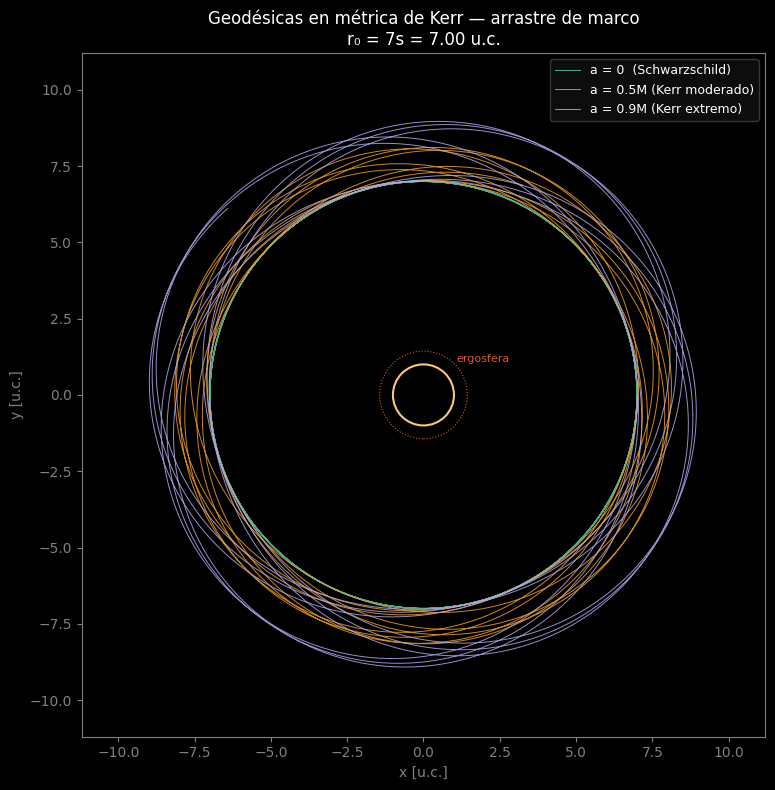

In [30]:
r0_kerr = 7.0 * s   # radio inicial para comparativa

a_vals  = [0.0, 0.5, 0.9]   # a=0 → Schwarzschild puro
colores_kerr = ['#5DCAA5', '#EF9F27', '#AFA9EC']
etiquetas = [
    'a = 0  (Schwarzschild)',
    'a = 0.5M (Kerr moderado)',
    'a = 0.9M (Kerr extremo)'
]

fig, ax = plt.subplots(figsize=(8, 8), facecolor='black')
ax.set_facecolor('black')

for a_val, col, etiq in zip(a_vals, colores_kerr, etiquetas):
    try:
        xk, yk = integrar_kerr(r0_kerr, a_val * s)
        ax.plot(xk, yk, color=col, lw=0.7, alpha=0.85,
                label=etiq)
    except Exception as e:
        print(f"  a={a_val}: {e}")

# Agujero negro y horizontes
ax.add_patch(plt.Circle(
    (0, 0), r_s/2, color='black', zorder=5
))
ax.add_patch(plt.Circle(
    (0, 0), r_s/2, fill=False,
    edgecolor='#FAC775', lw=1.5, zorder=6
))
# Ergosfera (a = 0.9M)
r_ergo = s + np.sqrt(s**2 - (0.9*s)**2)
ax.add_patch(plt.Circle(
    (0, 0), r_ergo, fill=False,
    edgecolor='#D85A30', lw=0.8, linestyle=':'
))
ax.text(
    r_ergo * 0.75, r_ergo * 0.75,
    'ergosfera', color='#D85A30', fontsize=8
)

lim_k = r0_kerr * 1.6
ax.set_xlim(-lim_k, lim_k)
ax.set_ylim(-lim_k, lim_k)
ax.set_aspect('equal')
ax.legend(
    facecolor='#111', edgecolor='#444',
    labelcolor='white', fontsize=9
)
ax.set_title(
    'Geodésicas en métrica de Kerr — arrastre de marco\n'
    f'r₀ = 7s = {r0_kerr:.2f} u.c.',
    color='white', fontsize=12
)
ax.tick_params(colors='gray')
for sp_ in ax.spines.values(): sp_.set_edgecolor('gray')
ax.set_xlabel('x [u.c.]', color='gray')
ax.set_ylabel('y [u.c.]', color='gray')
plt.tight_layout()
plt.show()